In [15]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.cluster import KMeans
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('data_exjobb_070425.parquet')
df.head()


,TransactionId,SalePrice,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,3200000,56.742153,16.291778,48,143,480,36,0,60.0,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,1700000,57.278909,13.646019,54,120,750,32,0,114.0,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,3500000,58.328009,15.103299,47,169,592,30,0,NaN,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,11200000,57.739437,14.122176,128,250,3311,30,0,88.0,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,591000,57.784585,16.146614,112,87,3406,28,0,101.0,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [16]:
# Create functions

def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            # print(iterate-i, type(del_data[0,iterate-i]), data[0,iterate-i])
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i
    """
    for i in range(len(del_data[0,:])):
        print(i, type(del_data[0,i]), del_data[0,i])

    for i in range(len(data[0,:])):
    print(i, type(data[0,i]), data[0,i])
        """
    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization."""
    # This retains the relative position of the data points.
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature))

def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    for i in range(data.shape[axis]):
        norm_data[:,i] = normalize_feature(data[:,i])
    return norm_data

def clustering(data, cluster_size=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, metric=distance_type)
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)

def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector




def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector

def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

def show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan):
    """Creates a 3D plot of the clusters and their center of mass."""
    
    %matplotlib widget

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 1]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 2]
        z1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 3]
        ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
        xc1,yc1,zc1 = centers_of_mass[i-1, 1:4]
        print(i, xc1, yc1, zc1)
        ax.scatter(xc1,yc1,zc1, c = cmap(-i), s = 100)

    # xc2,yc2,zc2 = centers_of_mass[1, 1:4]

    # print("1", xc1, yc1, zc1)
    # print("2", xc2, yc2, zc2)

    ax.set_title('3D Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)

def compare_Euclidean(reference, comparables, k=3):
    """Takes a reference point and a matrix of comparable points and returns the first column of the comparable points (ID) and
    the Euclidean distances sorted by distance from low to high."""
    # abs_compare = np.abs(comparables[:,1:] - reference[1:])
    sq_compare = np.square(comparables[:,1:] - reference[1:])
    # print("sq_compare", sq_compare)
    sum_compare = np.sum(sq_compare, axis=1)
    # print("sum_compare", sum_compare)
    Euc_compare = np.sqrt(sum_compare)
    # print("Euc_compare", Euc_compare)

    # np.insert(Euc_compare, 0, comparables[:, 0].flatten())  # Insert IDs back
    # print(comparables[:, 0], Euc_compare)
    Euc_compare = np.vstack((comparables[:, 0], Euc_compare)).T
    # print("Euc_compare", Euc_compare)

    sorted_dis = Euc_compare[Euc_compare[:, 1].argsort()]   # Sort Euc_compare

    return sorted_dis[0:k, :]

    

# Outline
1. Find Clusters using hdbscan.
2. Find the centers of the clusters.
3. Reduce the dimensionality to the number of clusters and create a new vector space.
4. Find a suitable model for finding comparisons.

## TODO
1. Linear regression.
2. Neural network.
3. Prepare data (choose features)

# Change to np.array and choose features

Start with excluding the feature that are not int or float.
Later give the unused features numerical values and implement them as well.


In [18]:
dataframe = df.copy()
Targets = pd.DataFrame(dataframe['LogAdjSalePrice202006'])
# print(dataframe[f'{dataframe.axes[1][0]}'])
# to_drop = ['TransactionId', 'BaseAreaName', 'DesoArea', 'geometry', 'DistAnyCity', 'DistAnyWater', 'SalePrice', 'LogAdjSalePrice202006', 'LogSalePrice', 'AdjSalePrice202006']

# dataframe = dataframe.drop(to_drop, axis=1)
to_keep = ['Lat', 'Lon', 'DistAnyCity', 'DistAnyWater', 'MedianIncomeSEK', 'DistRailAnyKm', 'UnemploymentPctCounty', 'DistSkiAnyKm', 'DistAnyAirportKm', 
           'DistNordicAnyKm', 'MunicipalityPopulation', 'MedianRentMunicipality']
dataframe = dataframe[to_keep]
dataframe.head()

,Lat,Lon,DistAnyCity,DistAnyWater,MedianIncomeSEK,DistRailAnyKm,UnemploymentPctCounty,DistSkiAnyKm,DistAnyAirportKm,DistNordicAnyKm,MunicipalityPopulation,MedianRentMunicipality
0,56.742153,16.291778,978.863385,3056.657592,356.8,0.478466,8.5,178.823620,4.698136,100.605554,70329.0,1155.0
1,57.278909,13.646019,716.388730,631.777326,402.3,10.212138,6.9,16.627844,28.214986,21.926643,29635.0,999.0
2,58.328009,15.103299,1673.369851,1448.828181,320.4,1.720936,8.5,93.639574,47.765031,33.628013,27960.0,1046.0
3,57.739437,14.122176,2863.059016,125.364470,402.1,0.349192,6.9,42.599821,42.969812,5.317157,142427.0,1059.0
4,57.784585,16.146614,2526.876136,1080.963393,320.9,13.057750,8.5,155.423832,22.135869,0.000000,36655.0,909.0


In [95]:
# Chaning to numpy array
df = df.fillna(0)
data = df.to_numpy()

data, removed_indices = remove_non_numbers(data)
print("Removed indices:", removed_indices)



data = data.astype(float) # Changing from type object to float so that numpy functions work properly.

data_original = data.copy()

# Divide the data set into training and testing data
percent = 0.10  # Fraction used for testing
samples = int(len(data[:,None]) * percent)

training_data, testing_data = train_test_split(data, test_size=samples)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)


data_points = 200
play_data = data[0:data_points, 1:4] # Only using a part of the data.

data = play_data


Removed indices: {153: 153, 49: 49, 48: 48, 40: 40, 39: 39, 32: 32, 26: 26, 25: 25, 24: 24, 23: 23, 17: 17, 15: 15, 10: 10, 0: 0}
X1 shape:  (82467, 160)
X2 shape:  (9163, 160)


# Clustering

In [96]:
def create_clusterspan(sorted_clusters):
    clusterspan = np.zeros(number_of_clusters + 2)

    j = 0
    for i in range(len(sorted_clusters[:,0])-1):
        if sorted_clusters[i, 0] < sorted_clusters[i+1,0]:
            # print(sorted_clusters[i, 0])
            clusterspan[j+1] = i+1
            j += 1
    clusterspan[-1] = len(sorted_clusters[:,0])
    return clusterspan

# Normalizing the data
norm_data = normalize(data)

# Clustering
number_of_clusters, clustered_data = clustering(norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1

clusterspan = create_clusterspan(sorted_clusters)

print(sorted_clusters, number_of_clusters, clusterspan)

[[0.         0.56883888 0.11597433 0.5625    ]
 [0.         0.12834275 0.40186154 0.37053571]
 [0.         0.35474737 0.46165847 0.49107143]
 [0.         0.58414143 0.46670413 0.49107143]
 [0.         0.68413329 0.46794102 0.37053571]
 [0.         0.45086748 0.40787514 0.32142857]
 [0.         0.46372479 0.1110102  0.40178571]
 [0.         0.54395234 0.86128608 0.        ]
 [0.         0.79146445 0.28330436 0.41964286]
 [0.         0.57267752 0.89618534 0.40178571]
 [0.         0.46504736 0.28341532 0.37053571]
 [0.         0.26232025 0.09043786 0.11607143]
 [0.         0.62377003 0.3250681  0.13392857]
 [0.         0.89490623 0.46723669 0.33482143]
 [0.         0.03457186 0.36727972 0.51339286]
 [0.         0.13479075 0.01905686 0.49107143]
 [0.         0.2693327  0.56764221 0.12053571]
 [0.         0.04439211 0.38236023 0.37053571]
 [0.         0.13759566 0.02394652 0.23214286]
 [0.         0.52839056 0.19885356 0.375     ]
 [0.         0.17280702 0.08083401 0.14285714]
 [0.         

# Finding center-of-mass

1 0.35157946433988413 0.4680333921925603 0.25869360902255645
2 0.8213311068554534 0.4089540938598552 0.21031746031746026
3 0.08347132243289328 0.27084569989824897 0.2234492481203007
4 0.5198483189892877 0.09743123737025582 0.2091346153846154


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_97668/2948627137.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_97668/2948627137.py:89: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_97668/2948627137.py:92: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping w

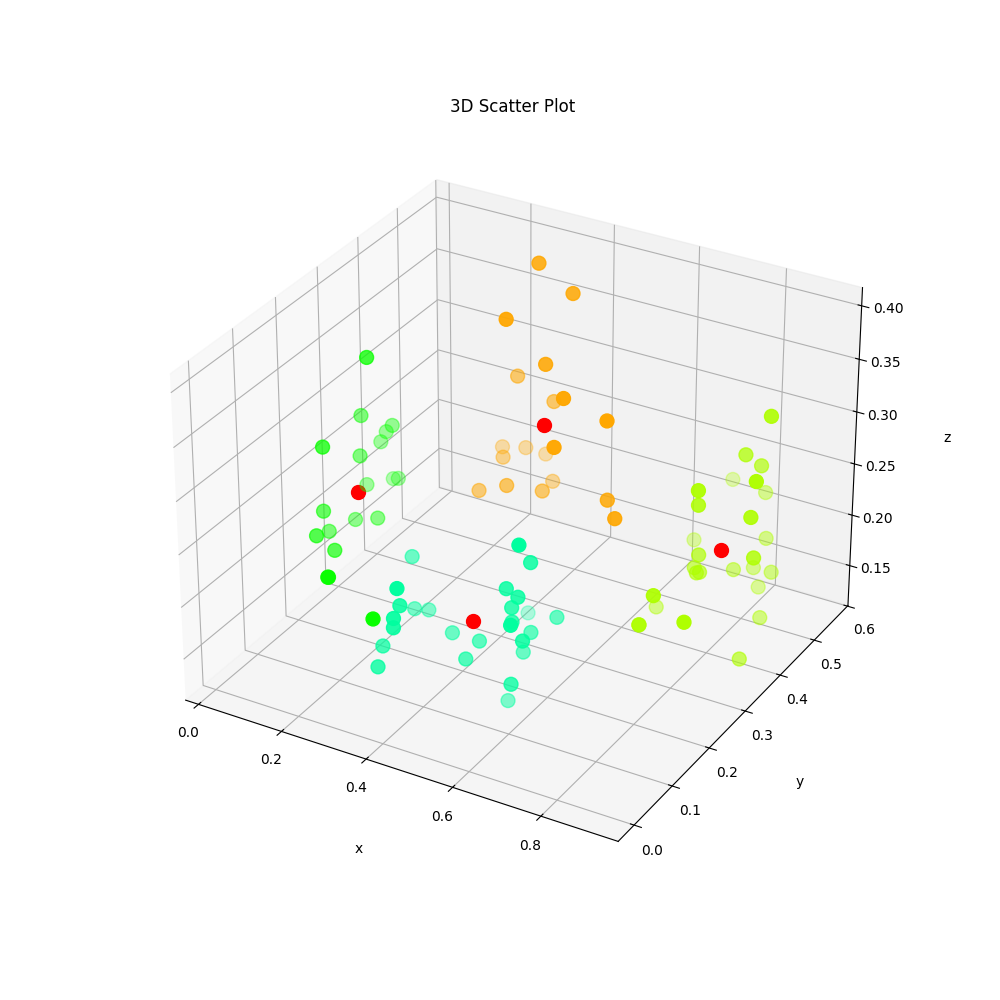

In [97]:
centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

In [98]:
CoM = np.delete(centers_of_mass, 0, axis=0)
print(CoM)
x = compare_Euclidean(sorted_clusters[0,:], CoM, np.shape(CoM)[0])

print(x)

[[2.         0.82133111 0.40895409 0.21031746]
 [3.         0.08347132 0.2708457  0.22344925]
 [4.         0.51984832 0.09743124 0.20913462]]
[[4.         0.35722684]
 [2.         0.52308891]
 [3.         0.6119822 ]]


# Finding minimal cluster size

In [133]:
# Improved Silhouette method

def cluster_silhouette(clusterdata, CS, cluster_index, CoM):
    # print(CS, CS[cluster_index], CS[cluster_index+1])
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    other_clusters = np.delete(CoM, cluster_index-1, axis=0)
    # nearest_cluster_index = compare_Euclidean(ref_point, other_clusters, np.shape(other_clusters)[0])[0, 0]

    n = np.shape(current_cluster)[0] # Data points in current cluster
    if n<2:
        return 0.0
    dis_cur_cluster = 0
    NoOC = np.shape(other_clusters)[0] # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    # print("NoOC",NoOC)
    for j in range(0, n):
        
        ref_point = current_cluster[j, :]
        # print(j, ref_point)
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n
        
        for l in range(0, NoOC):
            # nearest_cluster_index = int(compare_Euclidean(ref_point, other_clusters, np.shape(other_clusters)[0])[0, 0])
            nearest_cluster = clusterdata[int(CS[l]):int(CS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            # print("m", m)
            dis_cluster[l] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m
            # print("j", j, "l",l)
        # print("min", np.min(dis_cluster, axis=0))
        dis_near_cluster += np.min(dis_cluster, axis=0)
        
    # print("near:", dis_near_cluster, "cur:", dis_cur_cluster) #, "diff:", dis_near_cluster-dis_cur_cluster, "frac:", dis_near_cluster-dis_cur_cluster / dis_near_cluster)
    average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
    # print("max", np.maximum(dis_near_cluster, dis_cur_cluster))
    # print("average silhouette", average_silhouette)
    return average_silhouette

def Silhouette(SC, NoC, CoM, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    

    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    # CS = np.delete(CS, 0)
    for i in range(1, NoC):
        # print(i)
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i, CoM)
        
    # print(average_silhouette_clusters)

    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette

silhouette = Silhouette(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)
print(silhouette, number_of_clusters)

0.4286822976555946 2


In [134]:
def K_means_clustering(data, number_of_clusters, distance_type='euclidean'):
    clusterer = KMeans(number_of_clusters).fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)

def create_clusterspan_K_means(sorted_clusters):
    clusterspan = np.zeros(number_of_clusters + 1)

    j = 0
    for i in range(len(sorted_clusters[:,0])-1):
        if sorted_clusters[i, 0] < sorted_clusters[i+1,0]:
            # print(sorted_clusters[i, 0])
            clusterspan[j+1] = i+1
            j += 1
    clusterspan[-1] = len(sorted_clusters[:,0])
    return clusterspan

In [135]:
end = 20
start = 1
step_size = 1
max_iterations = (end-start) // step_size + 1
Sil_mat = np.zeros((max_iterations, 3))
# Sil_mat = np.zeros((data_points-2, 2))

for MCS in range(end, start, -step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
    # print(MCS)
    number_of_clusters, clustered_data = K_means_clustering(norm_data, MCS)
    # print(number_of_clusters, clustered_data)
    # print(number_of_clusters)
    if number_of_clusters < 2:
        Sil_mat[(MCS-start)//step_size] = MCS, 0, number_of_clusters
        continue
    sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
    sorted_clusters[:,0] +=1
    # print(sorted_clusters)

    clusterspan = create_clusterspan_K_means(sorted_clusters)
    # print(clusterspan)
    centers_of_mass = center_of_mass(number_of_clusters, clustered_data) # Kanske ta bort .copy() för bättre prestanda
    
    silhouette = Silhouette(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)
    Sil_mat[(MCS-start)//step_size] = MCS, silhouette, number_of_clusters
    # print(MCS, silhouette)
print(Sil_mat)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  4.28682298e-01  2.00000000e+00]
 [ 3.00000000e+00  2.69916854e-01  3.00000000e+00]
 [ 4.00000000e+00  1.61068693e-01  4.00000000e+00]
 [ 5.00000000e+00  1.50665477e-01  5.00000000e+00]
 [ 6.00000000e+00  1.11162887e-01  6.00000000e+00]
 [ 7.00000000e+00 -1.71123143e-01  7.00000000e+00]
 [ 8.00000000e+00  4.05198673e-02  8.00000000e+00]
 [ 9.00000000e+00  3.58851807e-02  9.00000000e+00]
 [ 1.00000000e+01 -1.19401119e-01  1.00000000e+01]
 [ 1.10000000e+01 -3.60812078e-02  1.10000000e+01]
 [ 1.20000000e+01 -8.02885498e-02  1.20000000e+01]
 [ 1.30000000e+01 -1.90970807e-02  1.30000000e+01]
 [ 1.40000000e+01 -4.71218474e-02  1.40000000e+01]
 [ 1.50000000e+01 -3.44081152e-02  1.50000000e+01]
 [ 1.60000000e+01  1.01962991e-02  1.60000000e+01]
 [ 1.70000000e+01 -6.69308965e-02  1.70000000e+01]
 [ 1.80000000e+01  6.01884602e-03  1.80000000e+01]
 [ 1.90000000e+01 -4.57451054e-02  1.90000000e+01]
 [ 2.00000000e+01  1.14165140e-

In [136]:
sm = pd.DataFrame(Sil_mat)
sm.to_parquet('silhouette_matrix.parquet')

In [137]:
df = pd.read_parquet('silhouette_matrix.parquet')
df.head()

,0,1,2
0,0.0,0.000000,0.0
1,2.0,0.428682,2.0
2,3.0,0.269917,3.0
3,4.0,0.161069,4.0
4,5.0,0.150665,5.0
